# **Diabetes 130-US Hospitals: EDA & Data Cleaning**

## **Introduction**

This notebook explores and cleans the Diabetes 130-US Hospitals dataset from the UCI Machine Learning Repository. The dataset contains 10 years of clinical care data (1999–2008) across 130 US hospitals.

## **Objective:** 
Predict whether a diabetic patient will be readmitted to hospital within 30 days of discharge.

## **Approach:** 
We follow the CRISP-DM methodology — this notebook covers the Data Understanding and Data Preparation phases.

In [1]:
# import libraries
import requests   # For sending HTTP requests to download the file
import zipfile    # For extracting the contents of the zip file
import os         # For creating folders and handling file paths

# Data Extraction

In [2]:
# Define the URL and where to save the data
url = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"

# os.path.join builds file paths
raw_dir = os.path.join("..", "data", "raw")
zip_path = os.path.join(raw_dir, "diabetes_raw.zip")

# Create the folder if it doesn't exist yet
os.makedirs(raw_dir, exist_ok=True)

# Download the zip file
# We set a User-Agent header so the server knows we're a browser-like client
headers = {"User-Agent": "Mozilla/5.0"}

print("Downloading dataset...")
response = requests.get(url, headers=headers, timeout=60)

# This will raise an error if the download failed
response.raise_for_status()

# Write the downloaded bytes to a zip file on disk
with open(zip_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded: {len(response.content) / 1024:.1f} KB")

# Unzip the file
with zipfile.ZipFile(zip_path, "r") as z:
    # List everything inside the zip so we know what we're working with
    print(f"\nFiles in the archive:")
    for name in z.namelist():
        print(f"  - {name}")

    # Extract all files into data
    z.extractall(raw_dir)

print(f"\nExtracted to: {os.path.abspath(raw_dir)}")

# Quick check — list what landed in data raw
print("\nContents of data/raw/:")
for f in os.listdir(raw_dir):
    print(f"  - {f}")

Downloaded: 3096.0 KB

Files in the archive:
  - diabetic_data.csv
  - IDS_mapping.csv

Extracted to: C:\Users\HP 1040 X360 G5\Desktop\Personal Projects\Diabetes Re-admission Project\data\raw

Contents of data/raw/:
  - diabetes_raw.zip
  - diabetic_data.csv
  - IDS_mapping.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set plot style for cleaner visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv("../data/raw/diabetic_data.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Initial Data Exploration

## Missing Values

The dataset uses `?` to represent missing values instead of NaN. Our first step is to convert these so that pandas can recognise them properly. We then assess how much data is missing in each column to decide whether to **drop**, **impute**, or **leave** each one.

In [5]:
# Replace ? with NaN
# The dataset uses '?' to represent missing values instead of leaving them blank
df.replace('?', np.nan, inplace=True)

# Verify it worked
print("Missing values per column (only those with missing):\n")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col, count in missing.items():
    print(f"  {col:25s} {count:>6,}  ({count/len(df)*100:.1f}%)")

Missing values per column (only those with missing):

  weight                    98,569  (96.9%)
  max_glu_serum             96,420  (94.7%)
  A1Cresult                 84,748  (83.3%)
  medical_specialty         49,949  (49.1%)
  payer_code                40,256  (39.6%)
  race                       2,273  (2.2%)
  diag_3                     1,423  (1.4%)
  diag_2                       358  (0.4%)
  diag_1                        21  (0.0%)


## Missingness Visualisation

The bar chart below makes it easy to see which columns are problematic. We can group them into three tiers:
- **Drop:** `weight` (96.9% missing) — almost no data exists, imputation would be meaningless
- **Decision required:** `medical_specialty` (49.1%) and `payer_code` (39.6%) — too much to impute reliably but may still carry some signal
- **Manageable:** `race` (2.2%), `diag_1/2/3` (<1.4%) — small enough to impute or drop affected rows

Note: `max_glu_serum` (94.7%) and `A1Cresult` (83.3%) appear missing but actually represent "test not taken" — which is itself informative. We will handle these differently.

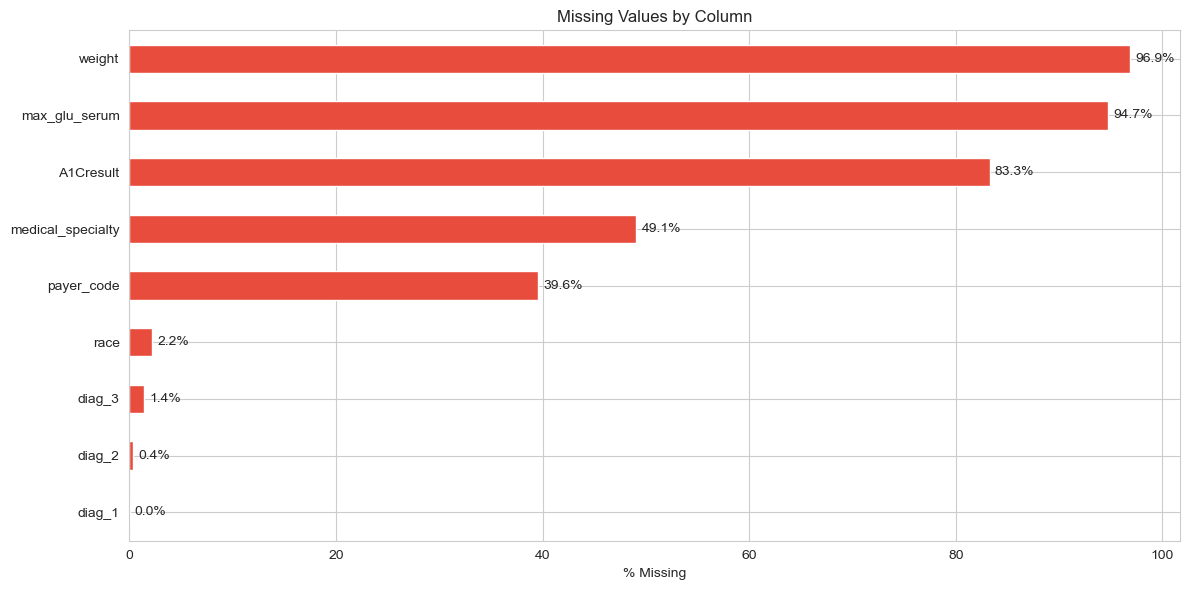

In [6]:
# Visualise missing values as a horizontal bar chart
cols_with_missing = df.columns[df.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
missing_pct = df[cols_with_missing].isnull().mean() * 100
missing_pct.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')

for i, (val, name) in enumerate(zip(missing_pct.sort_values(ascending=True),
                                      missing_pct.sort_values(ascending=True).index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../outputs/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Cleaning

Now that we understand the messiness, we will clean the data step by step:

1. Drop columns that are too sparse or carry no predictive signal
2. Remove rows that represent deceased or hospice patients (they cannot be readmitted)
3. Handle remaining missing values
4. Create the binary target variable

## Drop Unusable Columns

We remove columns for three reasons:
- **Near-total missingness:** `weight` (96.9% missing)
- **Not predictive / administrative:** `encounter_id`, `patient_nbr` (IDs, not features), `payer_code` (39.6% missing, insurance code — administrative rather than clinical)
- **Near-zero variance:** Medication columns where 95%+ of values are "No" — these carry almost no information for the model to learn from

In [7]:
# Audit: check how dominant the most common value is in each medication column
# If 95%+ of rows have the same value, the column has almost no variation
# and won't help the model distinguish readmitted vs non-readmitted patients

med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']

print("Medication column variance check:\n")
print(f"  {'Column':<30s} {'Top Value':<10s} {'% of Rows':>10s}  {'Action'}")
print(f"  {'-'*70}")

for col in med_cols:
    top_val = df[col].value_counts().index[0]
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    action = "DROP" if top_pct >= 95 else "KEEP"
    print(f"  {col:<30s} {top_val:<10s} {top_pct:>9.1f}%  {action}")

Medication column variance check:

  Column                         Top Value   % of Rows  Action
  ----------------------------------------------------------------------
  metformin                      No              80.4%  KEEP
  repaglinide                    No              98.5%  DROP
  nateglinide                    No              99.3%  DROP
  chlorpropamide                 No              99.9%  DROP
  glimepiride                    No              94.9%  KEEP
  acetohexamide                  No             100.0%  DROP
  glipizide                      No              87.5%  KEEP
  glyburide                      No              89.5%  KEEP
  tolbutamide                    No             100.0%  DROP
  pioglitazone                   No              92.8%  KEEP
  rosiglitazone                  No              93.7%  KEEP
  acarbose                       No              99.7%  DROP
  miglitol                       No             100.0%  DROP
  troglitazone                   No 

In [8]:
# Identify near-zero variance medication columns (95%+ single value)
nzv_cols = []

for col in med_cols:
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    if top_pct >= 95:
        nzv_cols.append(col)
        print(f"  Near-zero variance: {col:30s} -> '{df[col].value_counts().index[0]}' = {top_pct:.1f}%")

# Combine all columns to drop
cols_to_drop = ['encounter_id', 'patient_nbr', 'weight', 'payer_code'] + nzv_cols

print(f"\nTotal columns to drop: {len(cols_to_drop)}")
print(f"Columns before: {df.shape[1]}")

# Save patient_nbr before dropping — we need it later for leakage-aware splitting
patient_ids = df['patient_nbr'].copy()

df.drop(columns=cols_to_drop, inplace=True)

print(f"Columns after:  {df.shape[1]}")
print(f"\nRemaining columns:\n{list(df.columns)}")

  Near-zero variance: repaglinide                    -> 'No' = 98.5%
  Near-zero variance: nateglinide                    -> 'No' = 99.3%
  Near-zero variance: chlorpropamide                 -> 'No' = 99.9%
  Near-zero variance: acetohexamide                  -> 'No' = 100.0%
  Near-zero variance: tolbutamide                    -> 'No' = 100.0%
  Near-zero variance: acarbose                       -> 'No' = 99.7%
  Near-zero variance: miglitol                       -> 'No' = 100.0%
  Near-zero variance: troglitazone                   -> 'No' = 100.0%
  Near-zero variance: tolazamide                     -> 'No' = 100.0%
  Near-zero variance: examide                        -> 'No' = 100.0%
  Near-zero variance: citoglipton                    -> 'No' = 100.0%
  Near-zero variance: glyburide-metformin            -> 'No' = 99.3%
  Near-zero variance: glipizide-metformin            -> 'No' = 100.0%
  Near-zero variance: glimepiride-pioglitazone       -> 'No' = 100.0%
  Near-zero variance: met

## Remove Deceased and Hospice Patients

Patients who died during their hospital stay or were discharged to hospice care cannot be readmitted. Including them would distort the model — they are guaranteed "not readmitted" cases for a non-clinical reason. We identify these using the `discharge_disposition_id` column:
- 11 = Expired (died)
- 13 = Hospice / home
- 14 = Hospice / medical facility
- 19, 20, 21 = Expired (Medicaid/hospice variants)

In [9]:
# IDs representing death or hospice discharge
expired_ids = [11, 13, 14, 19, 20, 21]

rows_before = len(df)
expired_mask = df['discharge_disposition_id'].isin(expired_ids)
print(f"Rows flagged as expired/hospice: {expired_mask.sum():,}")

# Also remove these from our saved patient IDs
patient_ids = patient_ids[~expired_mask]

df = df[~expired_mask].reset_index(drop=True)
patient_ids = patient_ids.reset_index(drop=True)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {len(df):,}")
print(f"Removed:     {rows_before - len(df):,}")

Rows flagged as expired/hospice: 2,423
Rows before: 101,766
Rows after:  99,343
Removed:     2,423


## Handle Remaining Missing Values

For the remaining columns with missing data:
- **`race`** (2.2% missing): We fill these with "Unknown" since the proportion is small and dropping rows would waste data
- **`medical_specialty`** (49.1% missing): We fill with "Unknown" — while nearly half is missing, the column may still carry signal for the cases where a specialty is recorded
- **`diag_1`, `diag_2`, `diag_3`**: We fill with "0" (no diagnosis recorded) since the missingness is very small
- **`max_glu_serum` and `A1Cresult`**: These are already handled — NaN means "test not taken", which we recode as "None" (a valid clinical category)

In [10]:
# Fill missing categorical values
df['race'].fillna('Unknown', inplace=True)
df['medical_specialty'].fillna('Unknown', inplace=True)
df['diag_1'].fillna('0', inplace=True)
df['diag_2'].fillna('0', inplace=True)
df['diag_3'].fillna('0', inplace=True)

# max_glu_serum and A1Cresult: NaN means test was not performed
df['max_glu_serum'].fillna('None', inplace=True)
df['A1Cresult'].fillna('None', inplace=True)

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"Total remaining missing values: {remaining_missing}")

Total remaining missing values: 0


C:\Users\HP 1040 X360 G5\AppData\Local\Temp\ipykernel_32240\701543453.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['race'].fillna('Unknown', inplace=True)
C:\Users\HP 1040 X360 G5\AppData\Local\Temp\ipykernel_32240\701543453.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

## Create the Binary Target Variable

The original `readmitted` column has three values:
- `<30` — readmitted within 30 days
- `>30` — readmitted after 30 days  
- `NO` — not readmitted

We create a binary target: **1** = readmitted within 30 days, **0** = everything else.

In [11]:
# Create binary target: 1 = readmitted within 30 days
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

# Drop the original 3-class column
df.drop(columns=['readmitted'], inplace=True)

print("Binary target distribution:")
print(df['readmitted_30'].value_counts())
print(f"\nPositive class rate: {df['readmitted_30'].mean()*100:.1f}%")

Binary target distribution:
readmitted_30
0    88029
1    11314
Name: count, dtype: int64

Positive class rate: 11.4%


## Remove Duplicate Patient Encounters

Some patients have multiple encounters in the dataset. To avoid data leakage, we keep only the **first encounter** per patient. We will also use the saved `patient_nbr` for group-aware train/test splitting later.

In [12]:
# Check how many duplicates exist
print(f"Rows before deduplication: {len(df):,}")
print(f"Unique patients: {patient_ids.nunique():,}")

# Keep only the first encounter per patient
df['patient_nbr'] = patient_ids
df = df.drop_duplicates(subset='patient_nbr', keep='first').reset_index(drop=True)

print(f"Rows after deduplication:  {len(df):,}")
print(f"Removed: {len(patient_ids) - len(df):,} duplicate encounters")

# Drop patient_nbr again (it's an ID, not a feature)
df.drop(columns=['patient_nbr'], inplace=True)

Rows before deduplication: 99,343
Unique patients: 69,990
Rows after deduplication:  69,990
Removed: 29,353 duplicate encounters


### Target Variable Distribution

Let's visualise the target variable after all our cleaning steps to confirm the class imbalance we need to address during modelling.

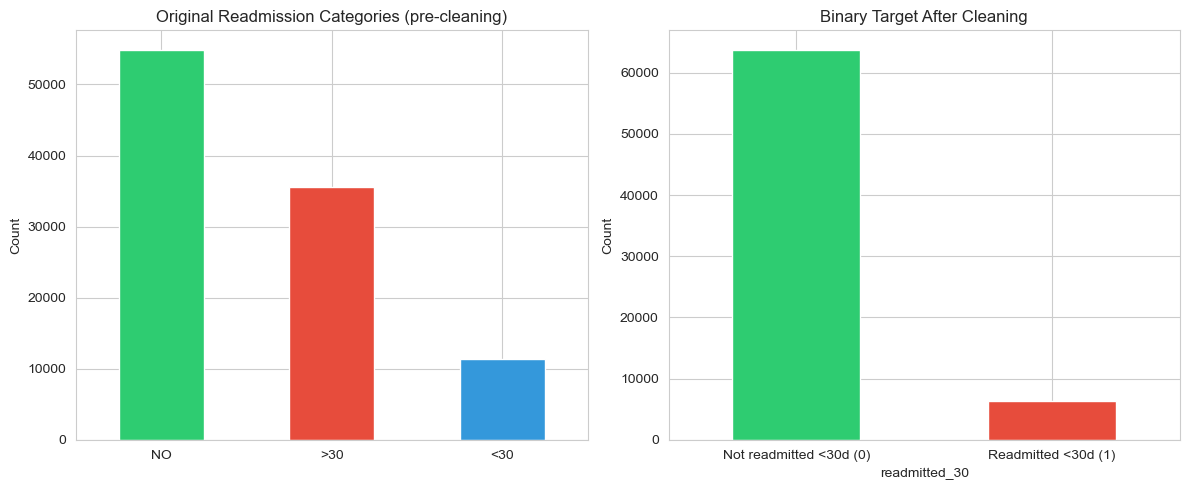

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original 3-class (for reference)
pd.Series({'NO': 54864, '>30': 35545, '<30': 11357}).plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Original Readmission Categories (pre-cleaning)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Cleaned binary target
df['readmitted_30'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xticklabels(['Not readmitted <30d (0)', 'Readmitted <30d (1)'], rotation=0)
axes[1].set_title('Binary Target After Cleaning')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Leakage Check

Some patients appeared multiple times in the original dataset. The chart below shows the distribution before we deduplicated. If the same patient appeared in both train and test sets, the model could "memorise" patient-specific patterns rather than learning generalisable clinical signals.

We addressed this by keeping only the first encounter per patient. During modelling, we will also verify the split is clean.

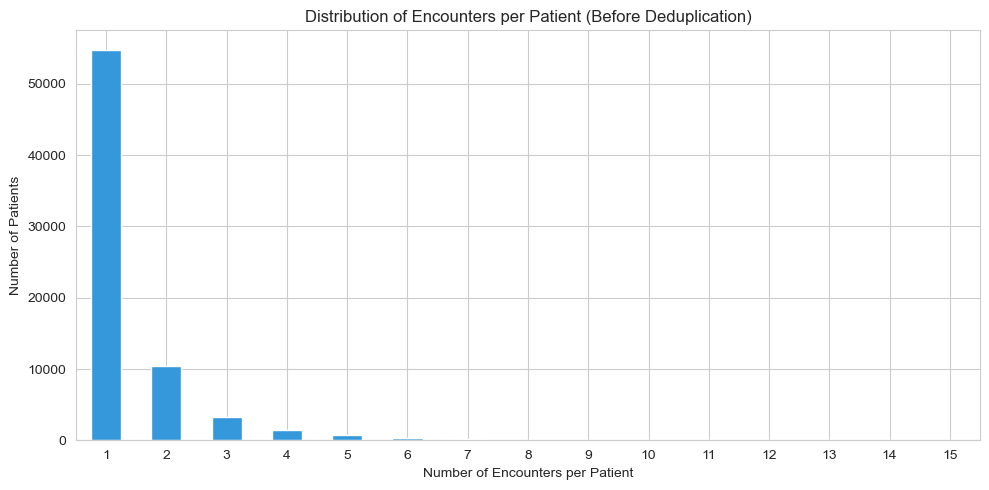

Patients with 1 encounter:   54,745
Patients with 2+ encounters:  16,773
Max encounters for 1 patient: 40


In [14]:
# Use original data to show the distribution before dedup
original_df = pd.read_csv("../data/raw/diabetic_data.csv")
encounters_per_patient = original_df['patient_nbr'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
encounters_per_patient.value_counts().sort_index().head(15).plot(kind='bar', ax=ax, color='#3498db')
ax.set_xlabel('Number of Encounters per Patient')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Encounters per Patient (Before Deduplication)')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/encounters_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Patients with 1 encounter:   {(encounters_per_patient == 1).sum():,}")
print(f"Patients with 2+ encounters:  {(encounters_per_patient > 1).sum():,}")
print(f"Max encounters for 1 patient: {encounters_per_patient.max()}")

# Exploratory Data Analysis (EDA)

Now that the data is clean, we explore the relationships between features and our target variable (30-day readmission). This helps us understand which features are likely to be predictive and informs our feature engineering decisions.

## Demographics vs Readmission

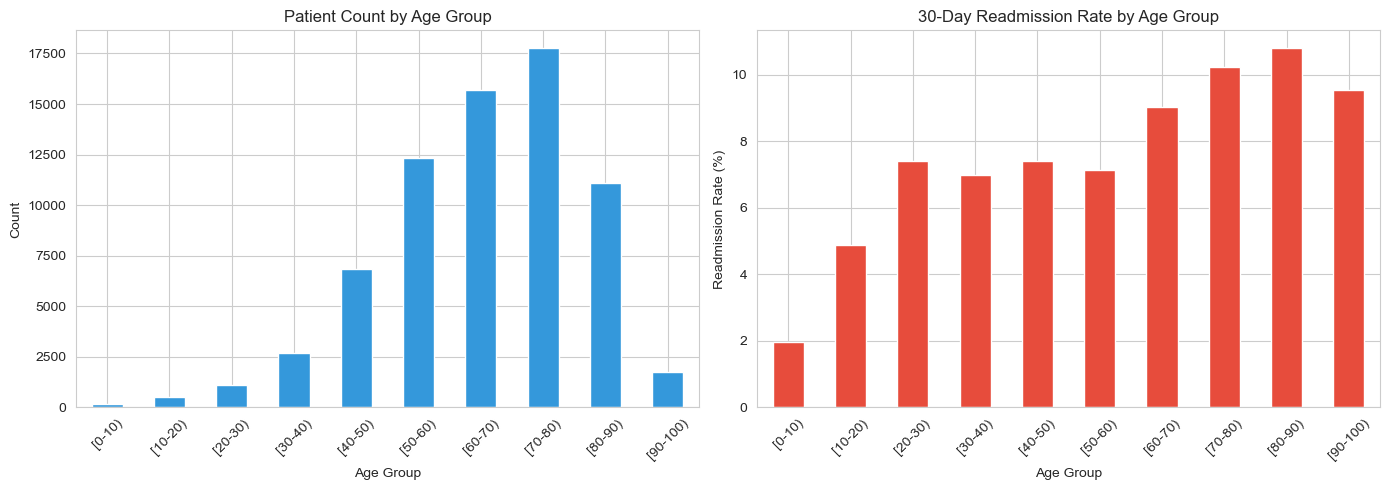

In [15]:
# How does readmission rate vary across age groups?
age_readmit = df.groupby('age')['readmitted_30'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of patients per age group
df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Patient Count by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Readmission rate by age group
age_readmit.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('30-Day Readmission Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/age_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- The dataset is dominated by older patients — the 60–80 age range accounts for the most encounters, which makes sense for a diabetic population
- Readmission rate increases steadily with age: children (0–10) have only ~2% readmission rate, while patients aged 70–90 have the highest rates at ~10%
- This suggests age is a meaningful predictor — older diabetic patients face higher readmission risk, likely due to more complex comorbidities and frailer health

## Race and Gender vs Readmission

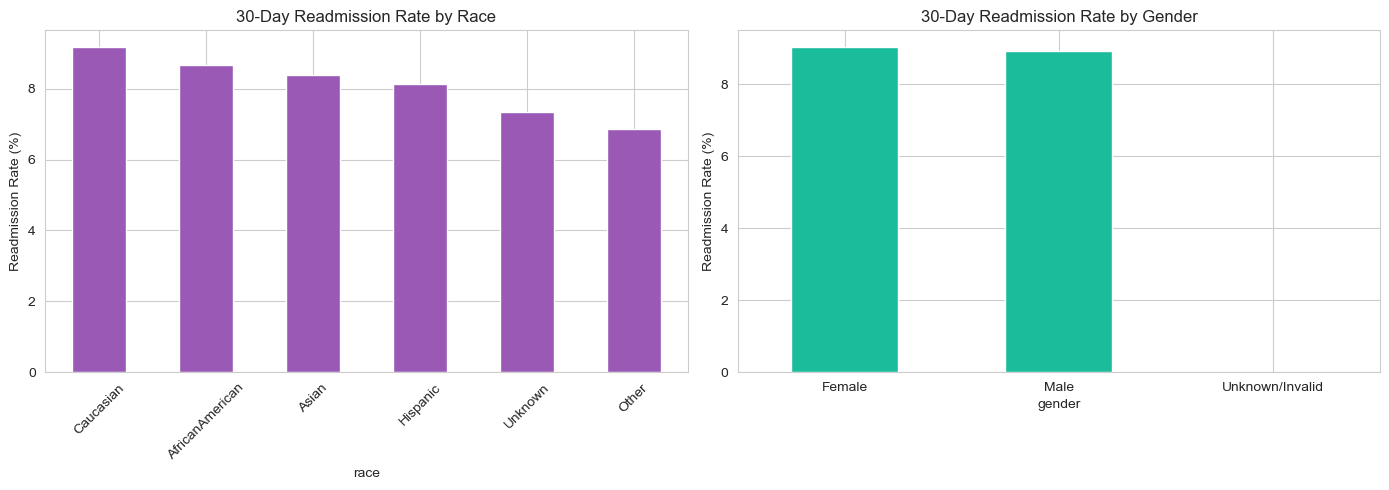

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Readmission rate by race
race_readmit = df.groupby('race')['readmitted_30'].mean() * 100
race_readmit.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#9b59b6')
axes[0].set_title('30-Day Readmission Rate by Race')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Readmission rate by gender
gender_readmit = df.groupby('gender')['readmitted_30'].mean() * 100
gender_readmit.plot(kind='bar', ax=axes[1], color='#1abc9c')
axes[1].set_title('30-Day Readmission Rate by Gender')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/demographics_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- **Race:** Readmission rates are relatively similar across racial groups (7–9%), with Caucasian patients slightly higher at ~9% and "Other" slightly lower at ~7%. The differences are small, suggesting race alone is not a strong predictor
- **Gender:** Male and female readmission rates are virtually identical (~8.5–9%), and the 3 Unknown/Invalid rows show 0% readmission (too few cases to draw any conclusion). Gender is unlikely to be a strong predictor on its own
- These demographic features may still contribute in combination with clinical features during modelling

## Numerical Features Distribution

We examine the distributions of key numerical features. Skewed distributions may need transformation, and differences between readmitted and non-readmitted groups can highlight predictive features.

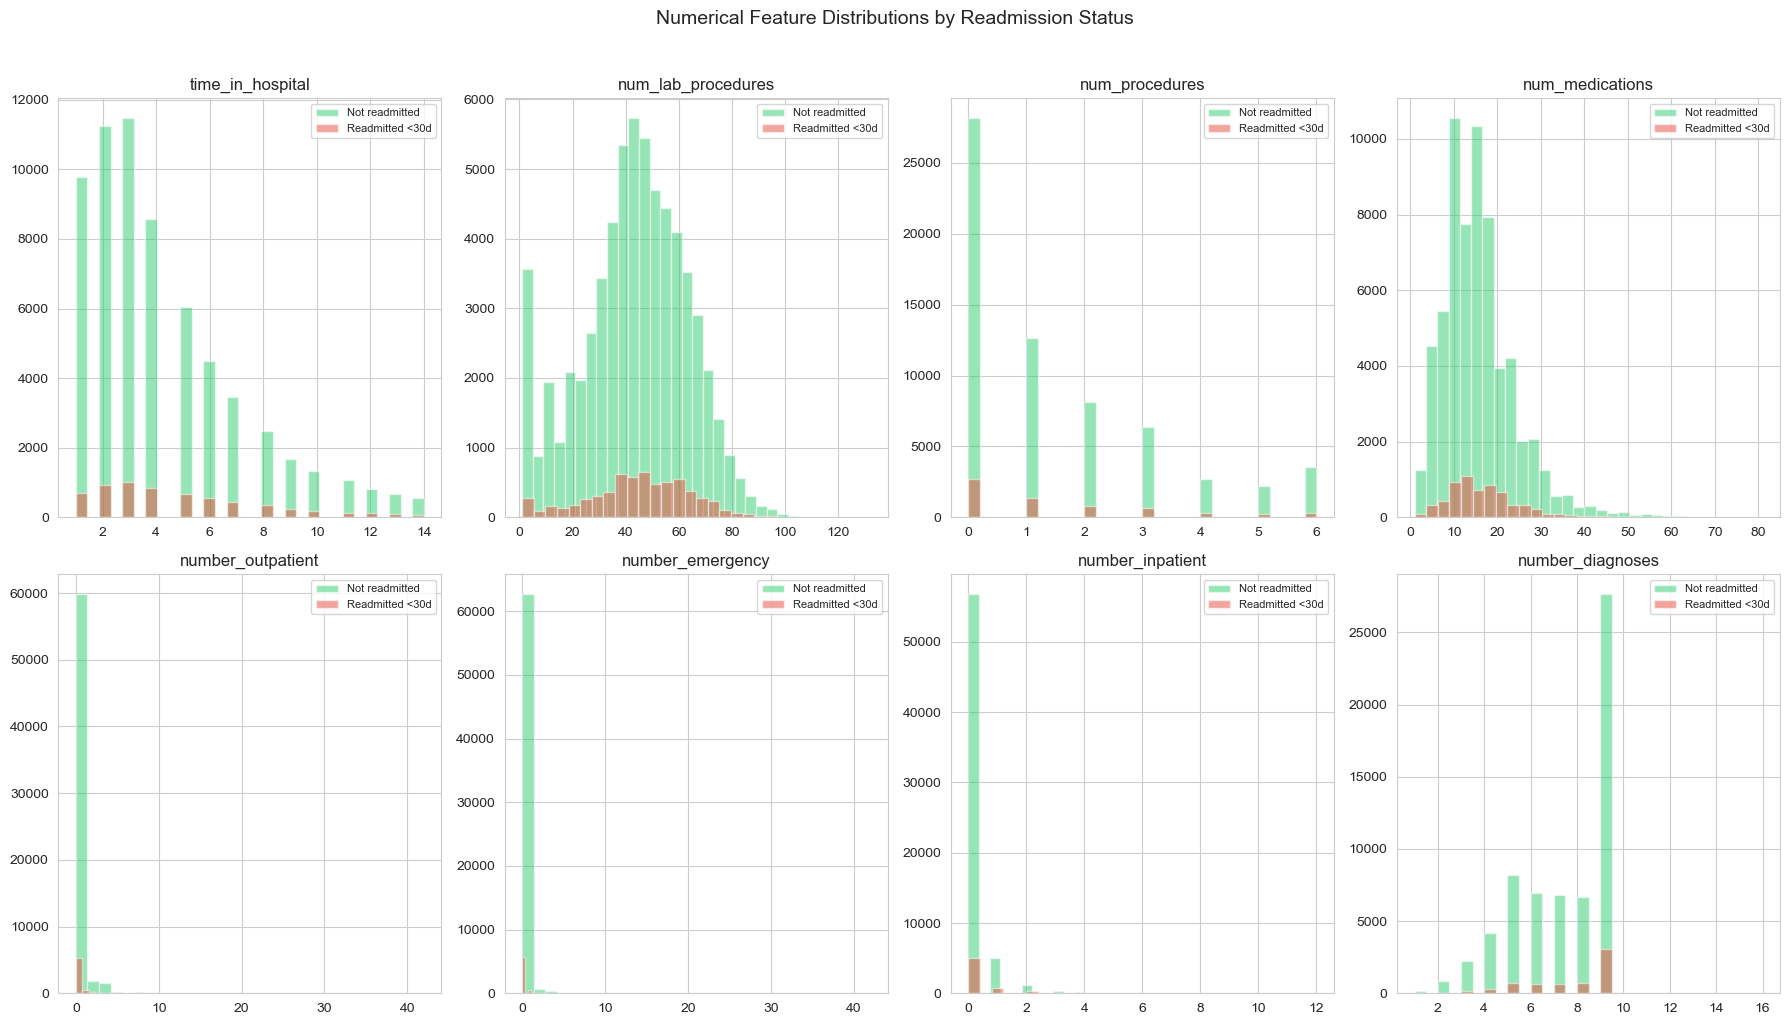

In [17]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Plot distribution split by readmission status
    df[df['readmitted_30'] == 0][col].hist(ax=axes[i], bins=30, alpha=0.5, 
                                             label='Not readmitted', color='#2ecc71')
    df[df['readmitted_30'] == 1][col].hist(ax=axes[i], bins=30, alpha=0.5, 
                                             label='Readmitted <30d', color='#e74c3c')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Readmission Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- **time_in_hospital:** Right-skewed, most stays are 1–5 days. Readmitted patients show a slightly longer tail, suggesting longer stays may signal higher risk
- **num_lab_procedures:** Roughly normally distributed around 40–50 tests. The distributions overlap heavily between readmitted and non-readmitted groups
- **num_procedures:** Heavily right-skewed — most patients have 0–1 procedures. Limited variation to distinguish the groups
- **num_medications:** Right-skewed with a peak around 10–15. Readmitted patients appear to use slightly more medications
- **number_outpatient, number_emergency:** Extremely skewed — the vast majority of patients have 0 prior visits. These are sparse features but may be important when non-zero
- **number_inpatient:** Also heavily skewed toward 0, but readmitted patients visibly have more prior inpatient visits — this is a promising predictor
- **number_diagnoses:** More evenly distributed (2–9 range). Readmitted patients trend slightly higher, suggesting sicker patients with more diagnoses face greater readmission risk

### Numerical Features — Summary Statistics by Readmission Status

Comparing the mean values of numerical features between readmitted and non-readmitted patients helps us spot which features differ most between the two groups.

In [18]:
# Compare means between readmitted and non-readmitted groups
comparison = df.groupby('readmitted_30')[num_cols].mean().T
comparison.columns = ['Not Readmitted (0)', 'Readmitted <30d (1)']
comparison['Difference'] = comparison['Readmitted <30d (1)'] - comparison['Not Readmitted (0)']
comparison['% Difference'] = (comparison['Difference'] / comparison['Not Readmitted (0)'] * 100).round(1)

print("Mean values by readmission status:\n")
print(comparison.round(2).to_string())

Mean values by readmission status:

                    Not Readmitted (0)  Readmitted <30d (1)  Difference  % Difference
time_in_hospital                  4.22                 4.79        0.57          13.6
num_lab_procedures               42.68                44.91        2.23           5.2
num_procedures                    1.43                 1.42       -0.00          -0.1
num_medications                  15.57                16.62        1.05           6.7
number_outpatient                 0.28                 0.31        0.03          11.6
number_emergency                  0.10                 0.15        0.05          50.5
number_inpatient                  0.16                 0.37        0.21         134.1
number_diagnoses                  7.20                 7.51        0.32           4.4


### **Findings:**

The mean comparison confirms what the histograms suggested. The features with the largest percentage difference between readmitted and non-readmitted patients are:

1. **number_inpatient** — by far the strongest signal. Readmitted patients have substantially more prior inpatient visits, indicating a pattern of recurring hospitalisation
2. **number_emergency** — readmitted patients also have more prior emergency visits, reinforcing the "frequent flyer" pattern
3. **number_outpatient** — similar trend but weaker
4. **time_in_hospital and num_medications** — readmitted patients stay slightly longer and receive more medications, consistent with higher clinical complexity

Features like `num_lab_procedures` and `num_procedures` show minimal differences — they are less likely to be strong predictors on their own.

## Key Clinical Features vs Readmission

Insulin use and medication changes are clinically important for diabetic patients. Let's examine how they relate to readmission.

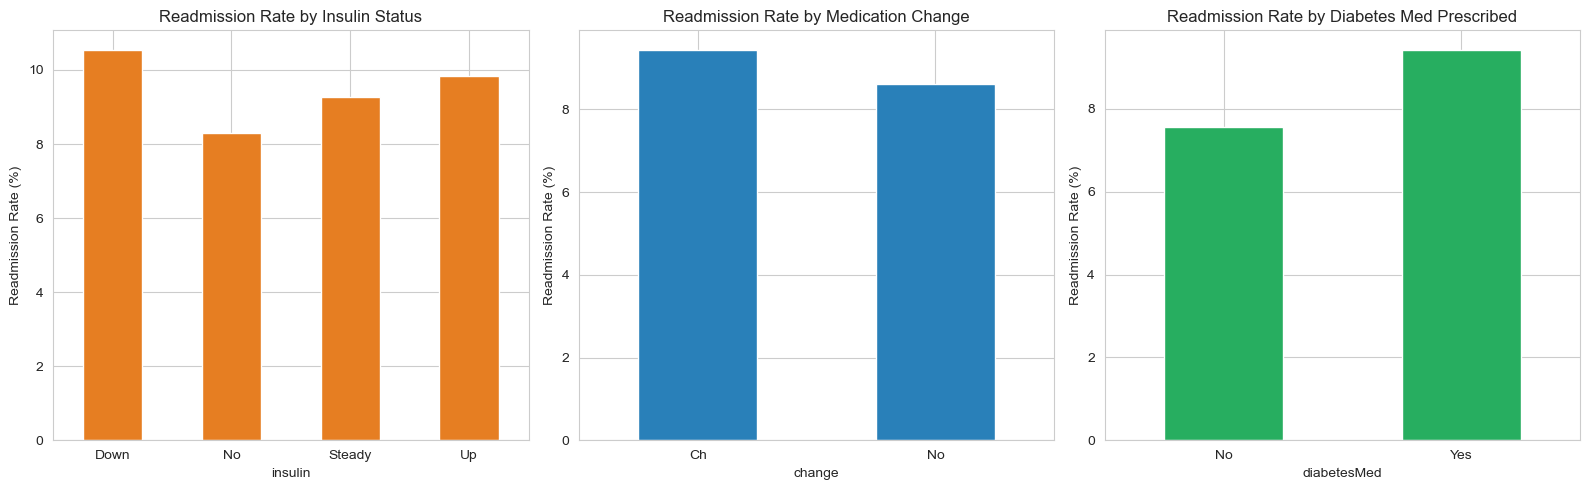

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Insulin usage vs readmission
insulin_readmit = df.groupby('insulin')['readmitted_30'].mean() * 100
insulin_readmit.plot(kind='bar', ax=axes[0], color='#e67e22')
axes[0].set_title('Readmission Rate by Insulin Status')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Medication change vs readmission
change_readmit = df.groupby('change')['readmitted_30'].mean() * 100
change_readmit.plot(kind='bar', ax=axes[1], color='#2980b9')
axes[1].set_title('Readmission Rate by Medication Change')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

# Diabetes medication prescribed vs readmission
diabmed_readmit = df.groupby('diabetesMed')['readmitted_30'].mean() * 100
diabmed_readmit.plot(kind='bar', ax=axes[2], color='#27ae60')
axes[2].set_title('Readmission Rate by Diabetes Med Prescribed')
axes[2].set_ylabel('Readmission Rate (%)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/clinical_features_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- **Insulin:** Patients whose insulin dosage was changed (Down 10.5%, Up 9.8%) have higher readmission rates than those not on insulin (No 8.3%) or on a steady dose (9.2%). Dosage instability may indicate poorly controlled diabetes
- **Medication change:** Patients who had any medication change ("Ch" 9.5%) have a slightly higher readmission rate than those with no change (8.9%). This could reflect more complex cases requiring treatment adjustments
- **Diabetes medication prescribed:** Patients prescribed diabetes medication (Yes 9.5%) have a higher readmission rate than those without (No 7.5%). This makes clinical sense — patients on medication generally have more advanced diabetes

These differences are modest (1–2 percentage points) but could be meaningful in a model that combines multiple weak signals.

## Correlation Heatmap — Numerical Features

A correlation heatmap shows how numerical features relate to each other and to the target. Highly correlated features may be redundant, and features correlated with the target are likely to be predictive.

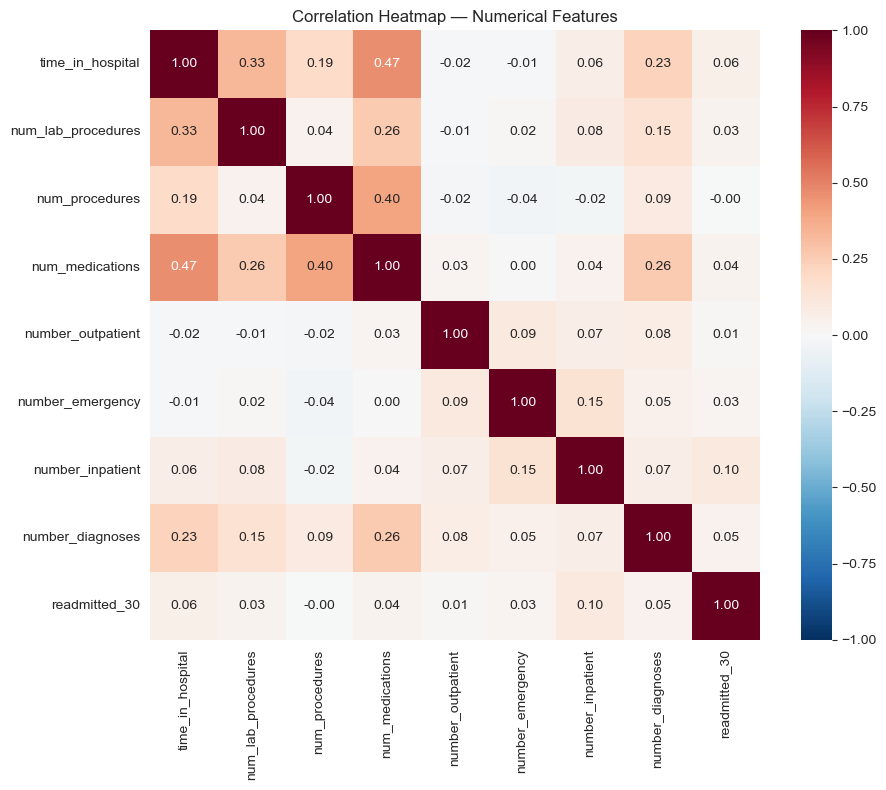

In [20]:
# Correlation matrix for numerical features including target
corr_cols = num_cols + ['readmitted_30']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numerical Features')

plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- **Correlations with target (readmitted_30):** All correlations are weak, with `number_inpatient` showing the strongest positive correlation at 0.10. This confirms that 30-day readmission is a difficult prediction problem — no single feature is a strong predictor
- **Feature-to-feature correlations:** 
  - `time_in_hospital` and `num_medications` are moderately correlated (0.47) — longer stays naturally involve more drugs
  - `num_procedures` and `num_medications` (0.40) — more interventions mean more medication
  - `time_in_hospital` and `num_lab_procedures` (0.33) — longer stays mean more tests
- These correlations make clinical sense and are not high enough to warrant dropping any features for multicollinearity
- The weak individual correlations with the target suggest we will need strong feature engineering and ensemble methods to achieve good predictive performance

## Admission Type and Discharge Disposition

These categorical features (mapped from IDs) may show different readmission patterns.

In [23]:
# Load the IDS mapping file to get meaningful names for admission and discharge IDs
# The file has multiple tables stacked vertically, so we need to parse each one separately

import csv

# Read the raw file
with open("../data/raw/IDS_mapping.csv", "r") as f:
    lines = f.readlines()

# Parse the admission_type_id mapping (starts at line 1)
admission_map = {}
discharge_map = {}
current_map = None

for line in lines:
    line = line.strip()
    if line.startswith("admission_type_id"):
        current_map = "admission"
        continue
    elif line.startswith("discharge_disposition_id"):
        current_map = "discharge"
        continue
    elif line.startswith("admission_source_id"):
        current_map = "source"
        continue

    # Parse the ID and description
    if current_map in ["admission", "discharge"] and "," in line:
        parts = line.split(",", 1)  # Split on first comma only
        try:
            id_val = int(parts[0])
            desc = parts[1].strip().strip('"')
            if current_map == "admission":
                admission_map[id_val] = desc
            elif current_map == "discharge":
                discharge_map[id_val] = desc
        except ValueError:
            continue

# Map the IDs to descriptions in our dataframe
df['admission_type'] = df['admission_type_id'].map(admission_map)
df['discharge_disposition'] = df['discharge_disposition_id'].map(discharge_map)

print("Admission Type Mapping:")
for k, v in sorted(admission_map.items()):
    print(f"  {k} -> {v}")

print(f"\nDischarge Disposition Mapping:")
for k, v in sorted(discharge_map.items()):
    print(f"  {k} -> {v}")

Admission Type Mapping:
  1 -> Emergency
  2 -> Urgent
  3 -> Elective
  4 -> Newborn
  5 -> Not Available
  6 -> NULL
  7 -> Trauma Center
  8 -> Not Mapped

Discharge Disposition Mapping:
  1 -> Discharged to home
  2 -> Discharged/transferred to another short term hospital
  3 -> Discharged/transferred to SNF
  4 -> Discharged/transferred to ICF
  5 -> Discharged/transferred to another type of inpatient care institution
  6 -> Discharged/transferred to home with home health service
  7 -> Left AMA
  8 -> Discharged/transferred to home under care of Home IV provider
  9 -> Admitted as an inpatient to this hospital
  10 -> Neonate discharged to another hospital for neonatal aftercare
  11 -> Expired
  12 -> Still patient or expected to return for outpatient services
  13 -> Hospice / home
  14 -> Hospice / medical facility
  15 -> Discharged/transferred within this institution to Medicare approved swing bed
  16 -> Discharged/transferred/referred another institution for outpatient ser

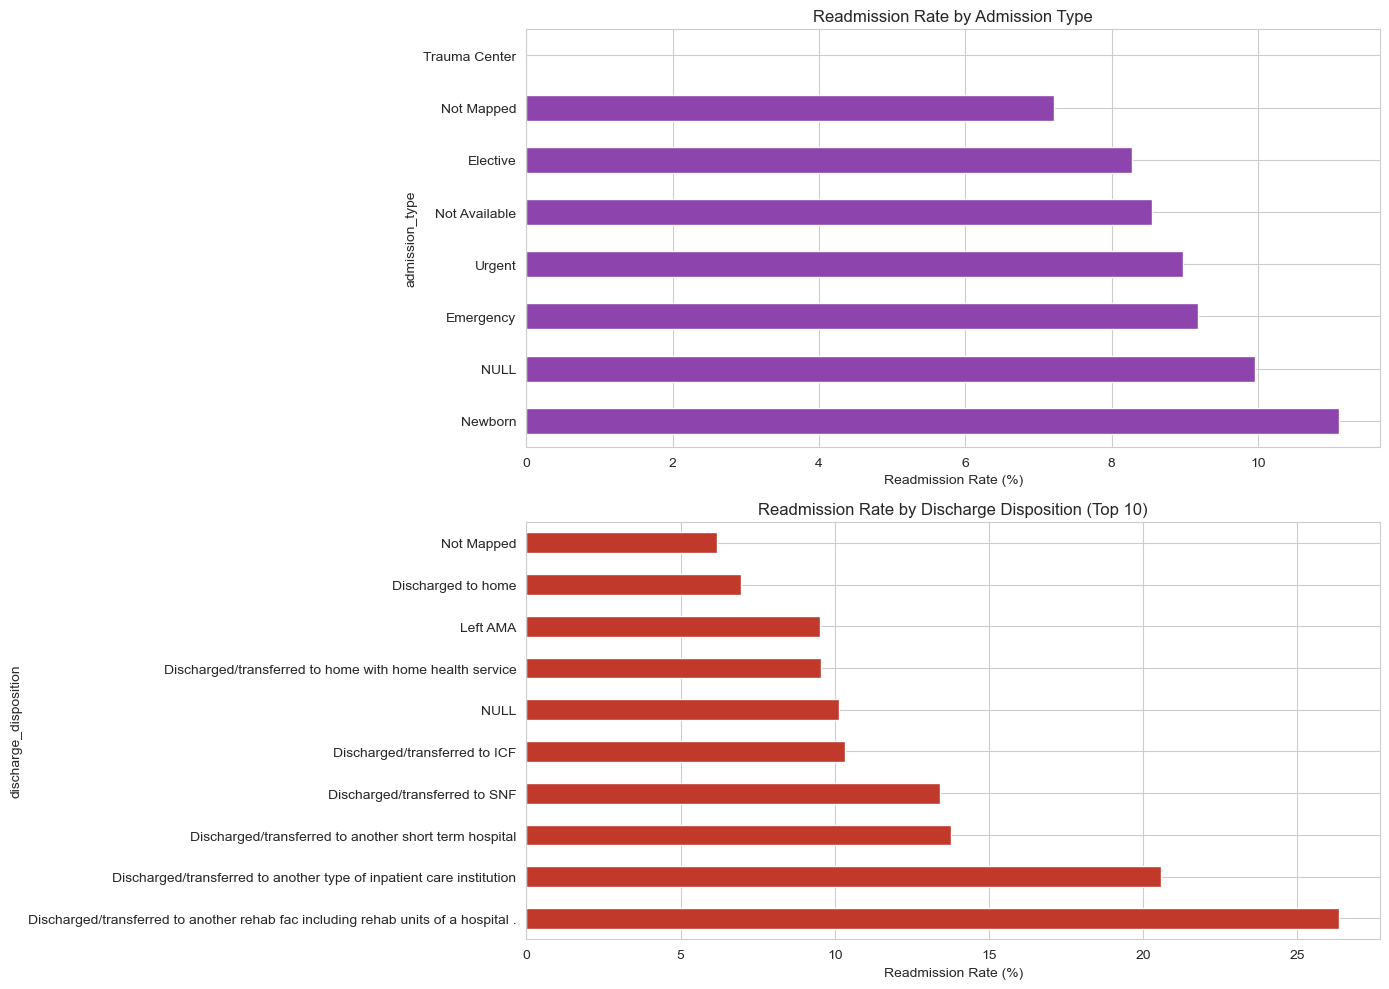

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Readmission rate by admission type — using names instead of IDs
adm_readmit = df.groupby('admission_type')['readmitted_30'].mean() * 100
adm_readmit.sort_values(ascending=False).plot(kind='barh', ax=axes[0], color='#8e44ad')
axes[0].set_title('Readmission Rate by Admission Type')
axes[0].set_xlabel('Readmission Rate (%)')

# Readmission rate by discharge disposition (top 10) — using names instead of IDs
top_discharge = df['discharge_disposition'].value_counts().head(10).index
discharge_readmit = df[df['discharge_disposition'].isin(top_discharge)].groupby(
    'discharge_disposition')['readmitted_30'].mean() * 100
discharge_readmit.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#c0392b')
axes[1].set_title('Readmission Rate by Discharge Disposition (Top 10)')
axes[1].set_xlabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig('../outputs/admission_discharge_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

### **Admission Type Findings:**
- **Newborn** has the highest readmission rate (11%), but this likely represents a very small, specialised group of neonatal diabetic cases and may not generalise
- **NULL** (10%) is suspiciously high — these are records where the admission type was not recorded, which could indicate data quality issues at certain hospitals
- **Emergency** (9.2%) and **Urgent** (9%) admissions have higher readmission rates than **Elective** (8.3%), which makes clinical sense — emergency patients are typically sicker and less prepared for discharge
- **Trauma Center** has the lowest rate (0.3%), though this is likely a tiny sample and may represent patients whose primary issue was trauma rather than diabetes

### **Discharge Disposition Findings:**
- **Transferred to rehab facility** has by far the highest readmission rate (26%) — these patients are clearly the most medically complex and unstable
- **Transferred to another inpatient care institution** (20%) and **transferred to another short-term hospital** (14%) follow the same pattern — patients sick enough to need further institutional care are at high risk of bouncing back
- **Transferred to SNF (Skilled Nursing Facility)** (13%) is also elevated — these patients need ongoing nursing support, indicating they are not well enough for independent recovery
- **Discharged to home** has one of the lowest rates (6%) — patients well enough to go home are much less likely to return within 30 days
- **Left AMA (Against Medical Advice)** (9.5%) is notable — these patients left before treatment was complete, which could contribute to readmission

This feature is one of the most informative in the dataset — where a patient goes after discharge is a strong signal of how likely they are to return.

# Feature Engineering

We now transform raw features into a format suitable for machine learning. This includes:
- Grouping raw ICD-9 diagnosis codes into meaningful clinical categories
- Encoding categorical variables as numbers
- Creating new features that capture clinical patterns identified during EDA

## ICD-9 Diagnosis Code Grouping

The `diag_1`, `diag_2`, and `diag_3` columns contain raw ICD-9 diagnosis codes (e.g., 250.83, 428, V27). There are 800+ unique values — far too many for a model to handle directly. We group them into broader clinical categories based on the standard ICD-9 chapter structure.

> ICD-9-CM chapter structure sourced from the WHO International Classification of Diseases, 9th Revision, as adopted by CMS (Centers for Medicare & Medicaid Services).

| Code Range | Clinical Category | Examples |
|---|---|---|
| 001–139 | Infectious & Parasitic | Tuberculosis, HIV, sepsis |
| 140–239 | Neoplasms | Cancers, tumours |
| 240–279 | Endocrine & Metabolic | **Diabetes (250.xx)**, thyroid disorders |
| 280–289 | Blood Diseases | Anaemia, clotting disorders |
| 290–319 | Mental Disorders | Depression, psychosis, dementia |
| 320–389 | Nervous System & Senses | Epilepsy, eye and ear conditions |
| 390–459 | Circulatory System | Heart disease, hypertension, stroke |
| 460–519 | Respiratory System | Pneumonia, asthma, COPD |
| 520–579 | Digestive System | GI bleeding, liver disease |
| 580–629 | Genitourinary System | Kidney disease, UTIs |
| 630–679 | Pregnancy & Childbirth | Obstetric complications |
| 680–709 | Skin & Subcutaneous | Skin infections, ulcers |
| 710–739 | Musculoskeletal | Arthritis, bone conditions |
| 740–759 | Congenital Anomalies | Birth defects |
| 760–779 | Perinatal Conditions | Newborn complications |
| 780–799 | Symptoms & Ill-Defined | Undiagnosed symptoms, fever |
| 800–999 | Injury & Poisoning | Fractures, drug reactions |
| E-codes | External Causes | How the injury occurred |
| V-codes | Supplementary | Follow-up visits, screening |

In [25]:
def map_icd9_to_category(code):
    """
    Maps an ICD-9 diagnosis code to a broad clinical category.
    Based on the ICD-9-CM chapter structure.
    
    Parameters:
        code: raw ICD-9 code as a string (e.g., '250.83', '428', 'V27')
    
    Returns:
        A string representing the clinical category
    """
    if code == '0' or pd.isnull(code):
        return 'Unknown'
    
    code = str(code).strip()
    
    # Handle E-codes (external causes of injury) and V-codes (supplementary)
    if code.startswith('E'):
        return 'External Causes'
    if code.startswith('V'):
        return 'Supplementary'
    
    # Try to convert to numeric for range-based grouping
    try:
        num = float(code)
    except ValueError:
        return 'Unknown'
    
    # ICD-9 chapter groupings
    if 1 <= num <= 139:
        return 'Infectious & Parasitic'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    elif 240 <= num <= 279:
        return 'Endocrine & Metabolic'    # Includes diabetes (250.xx)
    elif 280 <= num <= 289:
        return 'Blood Diseases'
    elif 290 <= num <= 319:
        return 'Mental Disorders'
    elif 320 <= num <= 389:
        return 'Nervous System & Senses'
    elif 390 <= num <= 459:
        return 'Circulatory System'       # Heart disease, hypertension
    elif 460 <= num <= 519:
        return 'Respiratory System'
    elif 520 <= num <= 579:
        return 'Digestive System'
    elif 580 <= num <= 629:
        return 'Genitourinary System'
    elif 630 <= num <= 679:
        return 'Pregnancy & Childbirth'
    elif 680 <= num <= 709:
        return 'Skin & Subcutaneous'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif 740 <= num <= 759:
        return 'Congenital Anomalies'
    elif 760 <= num <= 779:
        return 'Perinatal Conditions'
    elif 780 <= num <= 799:
        return 'Symptoms & Ill-Defined'
    elif 800 <= num <= 999:
        return 'Injury & Poisoning'
    else:
        return 'Unknown'

# Apply the mapping to all three diagnosis columns
df['diag_1_cat'] = df['diag_1'].apply(map_icd9_to_category)
df['diag_2_cat'] = df['diag_2'].apply(map_icd9_to_category)
df['diag_3_cat'] = df['diag_3'].apply(map_icd9_to_category)

# Check the primary diagnosis distribution
print("Primary Diagnosis Categories (diag_1_cat):\n")
print(df['diag_1_cat'].value_counts().to_string())

Primary Diagnosis Categories (diag_1_cat):

diag_1_cat
Circulatory System         21322
Endocrine & Metabolic       7599
Respiratory System          6451
Digestive System            6326
Symptoms & Ill-Defined      5503
Injury & Poisoning          4696
Musculoskeletal             4064
Genitourinary System        3415
Neoplasms                   2538
Skin & Subcutaneous         1780
Infectious & Parasitic      1685
Mental Disorders            1545
Supplementary                918
Nervous System & Senses      858
Blood Diseases               652
Pregnancy & Childbirth       586
Congenital Anomalies          41
Unknown                       10
External Causes                1


## Visualise Diagnosis Categories vs Readmission

Let's check how readmission rates vary across the clinical categories we just created — this validates whether the grouping captures meaningful clinical differences.

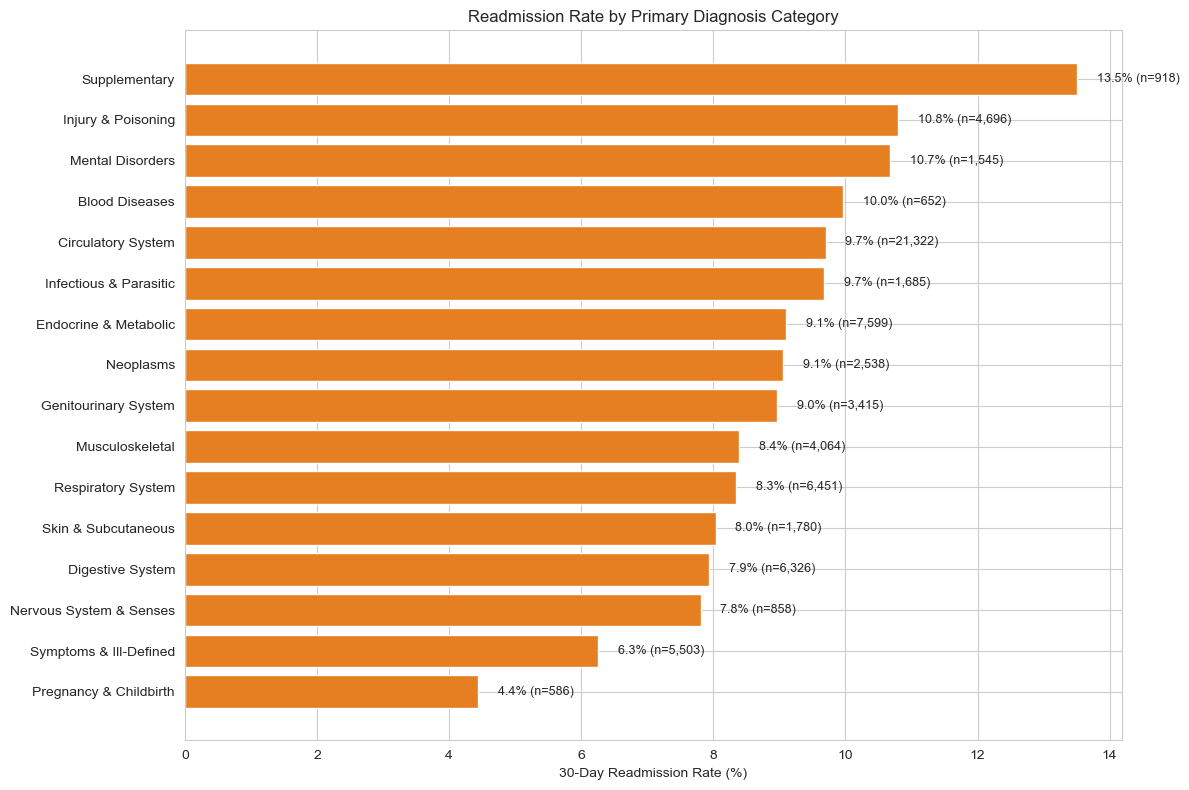

In [26]:
# Readmission rate by primary diagnosis category
diag_readmit = df.groupby('diag_1_cat')['readmitted_30'].agg(['mean', 'count'])
diag_readmit.columns = ['readmission_rate', 'patient_count']
diag_readmit['readmission_rate'] = diag_readmit['readmission_rate'] * 100

# Only show categories with at least 100 patients (small groups are unreliable)
diag_readmit = diag_readmit[diag_readmit['patient_count'] >= 100]
diag_readmit = diag_readmit.sort_values('readmission_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(diag_readmit.index, diag_readmit['readmission_rate'], color='#e67e22')

# Add patient count labels
for i, (rate, count) in enumerate(zip(diag_readmit['readmission_rate'], 
                                        diag_readmit['patient_count'])):
    ax.text(rate + 0.3, i, f'{rate:.1f}% (n={count:,})', va='center', fontsize=9)

ax.set_xlabel('30-Day Readmission Rate (%)')
ax.set_title('Readmission Rate by Primary Diagnosis Category')
plt.tight_layout()
plt.savefig('../outputs/diagnosis_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings:**
- **Supplementary (V-codes)** has the highest readmission rate at 13.5% — these are follow-up visits and screening appointments, so patients coming in for supplementary care are likely already managing ongoing conditions and are at higher risk of returning
- **Injury & Poisoning** (10.8%) and **Mental Disorders** (10.7%) also rank high — mental health conditions in particular are known to complicate diabetes management and reduce treatment adherence
- **Blood Diseases** (10.0%) and **Circulatory System** (9.7%) are elevated — cardiovascular comorbidities are extremely common in diabetic patients and add clinical complexity
- **Endocrine & Metabolic** (9.1%) — this is the category that includes diabetes itself (250.xx). Interestingly, it sits in the middle rather than at the top, suggesting that patients whose *primary* diagnosis is diabetes are not necessarily the highest readmission risk. It's the comorbidities that drive readmission
- **Pregnancy & Childbirth** has the lowest rate (4.4%) — these patients are typically younger and healthier, consistent with the age pattern we saw earlier
- **Circulatory System** has the largest sample size (n=21,322), making it the most reliable estimate and confirming that heart-related conditions are a major driver in this population

The ICD-9 grouping successfully captures meaningful clinical variation in readmission risk, validating our feature engineering approach.

## Create Derived Features

Based on our EDA findings, we create new features that capture patterns the raw data doesn't express directly:

1. **has_diabetes_primary** — whether the primary diagnosis is diabetes (ICD-9 250.xx), since this is a diabetes-focused dataset
2. **num_total_visits** — total prior visits (outpatient + emergency + inpatient), capturing overall healthcare utilisation
3. **num_active_medications** — count of how many of the remaining medication columns show active prescribing (Up, Down, or Steady rather than No)
4. **med_change_intensity** — how many individual medication dosages changed (Up or Down), capturing treatment instability

In [28]:
# Flag whether primary diagnosis is diabetes (ICD-9 codes starting with 250)
df['has_diabetes_primary'] = df['diag_1'].apply(
    lambda x: 1 if str(x).startswith('250') else 0
)
print(f"Patients with diabetes as primary diagnosis: {df['has_diabetes_primary'].sum():,} "
      f"({df['has_diabetes_primary'].mean()*100:.1f}%)")

# Total prior visits — captures overall healthcare utilisation
df['num_total_visits'] = (df['number_outpatient'] + 
                          df['number_emergency'] + 
                          df['number_inpatient'])
print(f"Mean total prior visits: {df['num_total_visits'].mean():.2f}")

# Count of active medications (any medication with Up, Down, or Steady)
# These are the medication columns we KEPT (not the near-zero variance ones we dropped)
active_med_cols = [col for col in df.columns 
                   if col in med_cols and col not in nzv_cols]
print(f"\nActive medication columns being counted: {active_med_cols}")

df['num_active_medications'] = df[active_med_cols].apply(
    lambda row: (row != 'No').sum(), axis=1
)
print(f"Mean active medications: {df['num_active_medications'].mean():.2f}")

# Medication change intensity — how many meds had dosage changed (Up or Down)
df['med_change_intensity'] = df[active_med_cols].apply(
    lambda row: row.isin(['Up', 'Down']).sum(), axis=1
)
print(f"Mean medication changes: {df['med_change_intensity'].mean():.2f}")

Patients with diabetes as primary diagnosis: 5,748 (8.2%)
Mean total prior visits: 0.56

Active medication columns being counted: ['metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
Mean active medications: 1.16
Mean medication changes: 0.26


### **Findings:**
- Only **8.2% of patients** have diabetes as their primary diagnosis, despite this being a diabetic patient dataset. This means most patients were admitted for other conditions (circulatory, respiratory, injury) while also having diabetes — reinforcing that comorbidities drive hospitalisations
- The mean total prior visits is **0.56**, meaning most patients had no prior visits in the preceding year. However, as we saw in the EDA, the patients who *do* have prior visits are at much higher readmission risk — this feature captures that signal
- Patients are on an average of **1.16 active medications** from the kept medication columns, with insulin being the most commonly prescribed
- The mean medication change intensity is **0.26**, meaning most patients had no dosage changes. When changes do occur, they may signal unstable diabetes management

## Encode Categorical Variables

Machine learning models need numerical inputs. We convert categorical columns using two approaches:

- **Label encoding** for ordinal/binary categories (e.g., age brackets have a natural order)
- **One-hot encoding** for nominal categories with no natural order (e.g., race, diagnosis category)

We also drop the original raw diagnosis columns (`diag_1`, `diag_2`, `diag_3`) since we now have the grouped categories, and drop the mapped name columns (`admission_type`, `discharge_disposition`) since we keep the numeric IDs.

In [29]:
# Drop columns we no longer need
# - Raw diagnosis codes (replaced by diag_1_cat, diag_2_cat, diag_3_cat)
# - Mapped name columns (we keep the numeric IDs for modelling)
cols_to_remove = ['diag_1', 'diag_2', 'diag_3', 'admission_type', 'discharge_disposition']
# Only drop columns that exist
cols_to_remove = [c for c in cols_to_remove if c in df.columns]
df.drop(columns=cols_to_remove, inplace=True)

# Encode age as ordinal (the brackets have a natural order)
age_order = {'[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
             '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9}
df['age'] = df['age'].map(age_order)

# Binary encode: change (Ch/No) and diabetesMed (Yes/No)
df['change'] = df['change'].map({'Ch': 1, 'No': 0})
df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})

# Encode max_glu_serum: ordinal scale
glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)

# Encode A1Cresult: ordinal scale
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
df['A1Cresult'] = df['A1Cresult'].map(a1c_map)

# Encode medication columns (the ones we kept): No=0, Steady=1, Down=2, Up=3
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
for col in active_med_cols:
    df[col] = df[col].map(med_map)

# One-hot encode nominal categoricals
nominal_cols = ['race', 'gender', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'medical_specialty']

# For medical_specialty, keep only top 10 categories to avoid too many columns
top_specialties = df['medical_specialty'].value_counts().head(10).index
df['medical_specialty'] = df['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")

Final dataset shape: 69,990 rows × 99 columns

Column types:
bool     71
int64    27
int32     1
Name: count, dtype: int64


## Final dataset check

In [31]:
# Check for any remaining non-numeric columns
non_numeric = df.select_dtypes(include=['object']).columns.tolist()
if non_numeric:
    print(f"WARNING: Non-numeric columns remaining: {non_numeric}")
else:
    print("All columns are numeric")

# Check for missing values
missing_total = df.isnull().sum().sum()
if missing_total > 0:
    print(f"WARNING: {missing_total} missing values remaining")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("No missing values")

# Target distribution
print(f"\nTarget distribution:")
print(df['readmitted_30'].value_counts())
print(f"Positive class rate: {df['readmitted_30'].mean()*100:.1f}%")

# Dataset shape
print(f"\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

All columns are numeric
No missing values

Target distribution:
readmitted_30
0    63705
1     6285
Name: count, dtype: int64
Positive class rate: 9.0%

Final shape: 69,990 rows × 99 columns


### **Final dataset summary:**
- **69,990 patients** (down from 101,766 after removing deceased/hospice patients and deduplicating)
- **99 features** (up from 50 raw columns, after one-hot encoding and feature engineering)
- **All columns numeric**, no missing values — ready for modelling
- **9.0% positive class rate** — confirms the class imbalance we need to handle with SMOTE or class weighting

In [33]:
df.to_csv('../data/processed/diabetic_processed.csv', index=False)
print(f"Saved processed dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Saved processed dataset: 69,990 rows × 99 columns


# Modelling

We now build and evaluate classification models to predict 30-day hospital readmission. Our approach:

1. Split the data into train and test sets (80/20)
2. Establish a baseline with Logistic Regression
3. Train a Random Forest and Gradient Boosting model
4. Handle class imbalance using SMOTE and class weighting
5. Evaluate using ROC-AUC and Precision-Recall metrics (accuracy is misleading with imbalanced classes)

## Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=['readmitted_30'])
y = df['readmitted_30']

# 80/20 split with stratification to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"\nClass balance in train: {y_train.mean()*100:.1f}% positive")
print(f"Class balance in test:  {y_test.mean()*100:.1f}% positive")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set: 55,992 rows
Test set:     13,998 rows

Class balance in train: 9.0% positive
Class balance in test:  9.0% positive


## Baseline: Logistic Regression

We start with Logistic Regression as our baseline model. It's simple, interpretable, and gives us a benchmark to beat. We use `class_weight='balanced'` to handle the class imbalance — this tells the model to pay more attention to the minority class (readmitted patients) by penalising misclassifications of that class more heavily.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# Train Logistic Regression with class weighting to handle imbalance
lr_model = LogisticRegression(
    class_weight='balanced',  # Automatically adjusts weights inversely proportional to class frequency
    max_iter=1000,            # Ensure convergence
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of positive class

# Evaluate
print("=== Logistic Regression (Baseline) ===\n")
print("Classification Report:")
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, lr_proba):.4f}")

=== Logistic Regression (Baseline) ===

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     12741
           1       0.13      0.54      0.21      1257

    accuracy                           0.62     13998
   macro avg       0.53      0.59      0.48     13998
weighted avg       0.86      0.62      0.70     13998

ROC-AUC Score: 0.6283
Average Precision Score: 0.1501


## Random Forest

Random Forest is an ensemble of decision trees that handles non-linear relationships and feature interactions well. It's also robust to different feature scales, so it doesn't require the scaled data.

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest with class weighting
rf_model = RandomForestClassifier(
    n_estimators=200,         # Number of trees
    class_weight='balanced',  # Handle imbalance
    max_depth=15,             # Prevent overfitting
    min_samples_leaf=20,      # Minimum samples per leaf node
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)
rf_model.fit(X_train, y_train)  # No scaling needed for tree-based models

# Predict on test set
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Random Forest ===\n")
print("Classification Report:")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, rf_proba):.4f}")

=== Random Forest ===

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.83     12741
           1       0.15      0.44      0.22      1257

    accuracy                           0.72     13998
   macro avg       0.54      0.59      0.52     13998
weighted avg       0.86      0.72      0.77     13998

ROC-AUC Score: 0.6461
Average Precision Score: 0.1553


## Gradient Boosting

Gradient Boosting builds trees sequentially, with each tree correcting the errors of the previous one. It often outperforms Random Forest on structured/tabular data. We use the same class weighting approach to handle imbalance.

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting
# Note: GradientBoostingClassifier doesn't support class_weight directly,
# so we use sample_weight to achieve the same effect
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=200,        # Number of boosting rounds
    learning_rate=0.1,       # Step size for each tree's contribution
    max_depth=5,             # Shallow trees prevent overfitting
    min_samples_leaf=20,
    random_state=42
)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)

# Predict on test set
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Gradient Boosting ===\n")
print("Classification Report:")
print(classification_report(y_test, gb_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, gb_proba):.4f}")
print(f"Average Precision Score: {average_precision_score(y_test, gb_proba):.4f}")

=== Gradient Boosting ===

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     12741
           1       0.15      0.52      0.23      1257

    accuracy                           0.69     13998
   macro avg       0.54      0.61      0.52     13998
weighted avg       0.87      0.69      0.75     13998

ROC-AUC Score: 0.6539
Average Precision Score: 0.1765


### Model Comparison Analysis

**Results Summary:**

| Model | ROC-AUC | Avg Precision | Recall (Class 1) | Precision (Class 1) |
|---|---|---|---|---|
| Logistic Regression | 0.6283 | 0.1501 | 0.54 | 0.13 |
| Random Forest | 0.6461 | 0.1553 | 0.44 | 0.15 |
| Gradient Boosting | 0.6539 | 0.1765 | 0.52 | 0.15 |

**Key observations:**

1. **Gradient Boosting performs best** with the highest ROC-AUC (0.6539) and Average Precision (0.1765), confirming that sequential boosting captures patterns that individual trees or linear models miss
2. **All models struggle with precision** — only 13–15% of flagged patients are actually readmitted. This is partly driven by the class imbalance (9% positive rate) and partly because the features have weak individual correlations with the target
3. **The recall-precision trade-off is visible:** Logistic Regression catches more readmitted patients (recall=0.54) but with more false alarms. Random Forest is more conservative (recall=0.44) but slightly more precise
4. **Overall performance is modest** — ROC-AUC scores in the 0.63–0.65 range indicate the models are learning some signal but the problem is inherently difficult. This is consistent with published research on this dataset, where most models achieve ROC-AUC between 0.60–0.68
5. **Clinical context matters:** Even modest predictive ability is useful in healthcare. A model that correctly identifies even half of high-risk patients allows clinicians to target discharge planning resources more efficiently than treating all patients the same

We will now try SMOTE (Synthetic Minority Oversampling) to see if generating synthetic examples of the minority class improves performance.

## SMOTE — Synthetic Minority Oversampling

SMOTE creates synthetic examples of the minority class (readmitted patients) by interpolating between existing minority samples. This gives the model more positive examples to learn from during training, without simply duplicating existing rows.

Important: SMOTE is applied **only to the training set** — the test set remains untouched to ensure our evaluation reflects real-world performance.

In [38]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_smote.value_counts().to_dict()}")
print(f"\nTraining set grew from {len(X_train):,} to {len(X_train_smote):,} rows")

Before SMOTE: {0: 50964, 1: 5028}
After SMOTE:  {0: 50964, 1: 50964}

Training set grew from 55,992 to 101,928 rows


## Retrain Models with SMOTE

We retrain all three models on the SMOTE-balanced training data and compare against the original results. With SMOTE we remove `class_weight='balanced'` since the classes are now balanced.

In [39]:
# Scale the SMOTE data for Logistic Regression
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled_smote = scaler.transform(X_test)

# --- Logistic Regression with SMOTE ---
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote_scaled, y_train_smote)
lr_smote_proba = lr_smote.predict_proba(X_test_scaled_smote)[:, 1]
lr_smote_pred = lr_smote.predict(X_test_scaled_smote)

print("=== Logistic Regression + SMOTE ===\n")
print(classification_report(y_test, lr_smote_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_smote_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, lr_smote_proba):.4f}")

# --- Random Forest with SMOTE ---
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)
rf_smote_proba = rf_smote.predict_proba(X_test)[:, 1]
rf_smote_pred = rf_smote.predict(X_test)

print("\n=== Random Forest + SMOTE ===\n")
print(classification_report(y_test, rf_smote_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_smote_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, rf_smote_proba):.4f}")

# --- Gradient Boosting with SMOTE ---
gb_smote = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
gb_smote.fit(X_train_smote, y_train_smote)
gb_smote_proba = gb_smote.predict_proba(X_test)[:, 1]
gb_smote_pred = gb_smote.predict(X_test)

print("\n=== Gradient Boosting + SMOTE ===\n")
print(classification_report(y_test, gb_smote_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, gb_smote_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, gb_smote_proba):.4f}")

=== Logistic Regression + SMOTE ===

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     12741
           1       0.12      0.04      0.06      1257

    accuracy                           0.89     13998
   macro avg       0.52      0.51      0.50     13998
weighted avg       0.84      0.89      0.86     13998

ROC-AUC: 0.5766
Avg Precision: 0.1127

=== Random Forest + SMOTE ===

              precision    recall  f1-score   support

           0       0.91      0.95      0.93     12741
           1       0.11      0.07      0.08      1257

    accuracy                           0.87     13998
   macro avg       0.51      0.51      0.50     13998
weighted avg       0.84      0.87      0.85     13998

ROC-AUC: 0.5498
Avg Precision: 0.1037

=== Gradient Boosting + SMOTE ===

              precision    recall  f1-score   support

           0       0.91      0.98      0.95     12741
           1       0.15      0.03      0.06      1257

 

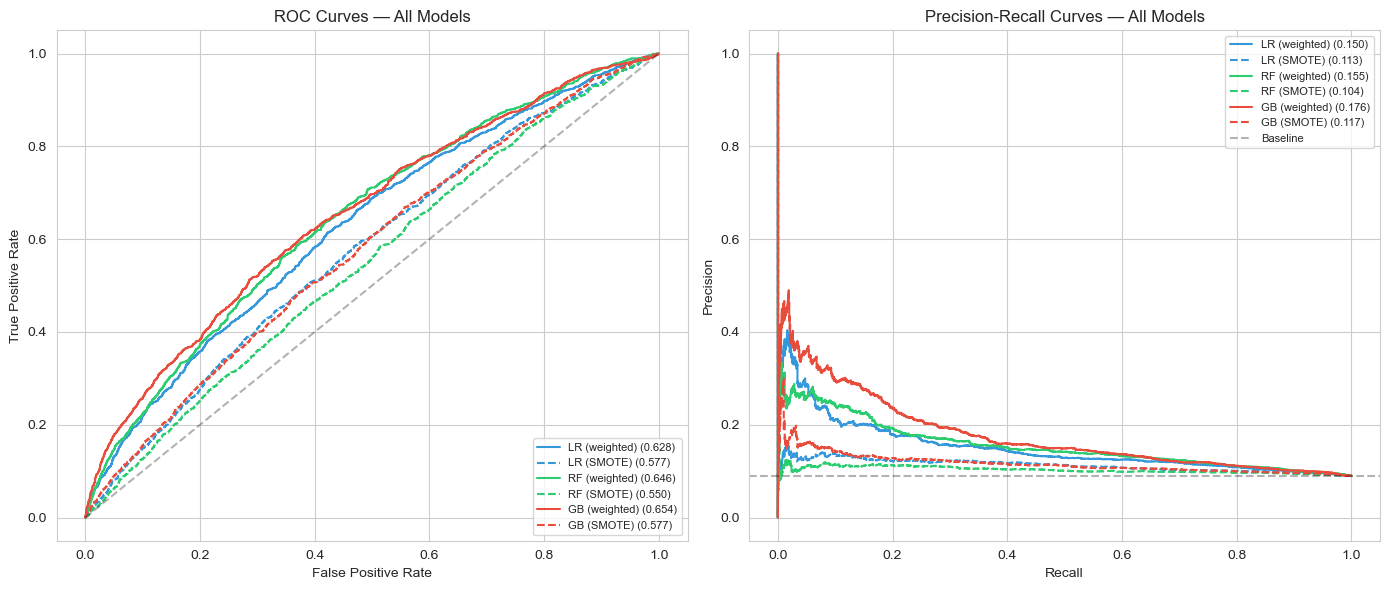


=== Full Model Comparison ===

Model                        ROC-AUC   Avg Precision
--------------------------------------------------
LR (weighted)                 0.6283          0.1501
LR (SMOTE)                    0.5766          0.1127
RF (weighted)                 0.6461          0.1553
RF (SMOTE)                    0.5498          0.1037
GB (weighted)                 0.6539          0.1765
GB (SMOTE)                    0.5770          0.1173


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# All models to compare
all_models = {
    'LR (weighted)': (lr_proba, '#3498db', '-'),
    'LR (SMOTE)': (lr_smote_proba, '#3498db', '--'),
    'RF (weighted)': (rf_proba, '#2ecc71', '-'),
    'RF (SMOTE)': (rf_smote_proba, '#2ecc71', '--'),
    'GB (weighted)': (gb_proba, '#e74c3c', '-'),
    'GB (SMOTE)': (gb_smote_proba, '#e74c3c', '--'),
}

# ROC Curves
for name, (proba, color, style) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linestyle=style, label=f'{name} ({auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=8)

# Precision-Recall Curves
for name, (proba, color, style) in all_models.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=color, linestyle=style, label=f'{name} ({ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== Full Model Comparison ===\n")
print(f"{'Model':<25s} {'ROC-AUC':>10s} {'Avg Precision':>15s}")
print(f"{'-'*50}")
for name, (proba, _, _) in all_models.items():
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    print(f"{name:<25s} {auc:>10.4f} {ap:>15.4f}")

### SMOTE vs Class Weighting Analysis

**Key finding: SMOTE hurt performance across all three models.**

| Model | ROC-AUC (Weighted) | ROC-AUC (SMOTE) | Change |
|---|---|---|---|
| Logistic Regression | 0.6283 | 0.5766 | -0.0517 |
| Random Forest | 0.6461 | 0.5498 | -0.0963 |
| Gradient Boosting | 0.6539 | 0.5770 | -0.0769 |

**Why SMOTE failed here:**

1. **Synthetic noise:** SMOTE creates new minority samples by interpolating between existing ones. But with 99 features and weak individual signals, the synthetic samples likely introduced noise rather than useful patterns — the model learned to fit artificial data points that don't reflect real patient characteristics
2. **Feature space is sparse:** Many of our features are one-hot encoded binary columns (race, diagnosis category, medical specialty). Interpolating between binary features creates fractional values (e.g., 0.4 for a race category) that don't represent real patients
3. **Class weighting is more appropriate here:** It achieves the same goal — making the model pay more attention to the minority class — without altering the actual training data. This preserves the real relationships in the data

**Conclusion:** Class weighting is the better imbalance-handling strategy for this dataset. **Gradient Boosting with class weighting remains our best model** with ROC-AUC of 0.6539 and Average Precision of 0.1765.

This finding is itself valuable — it demonstrates that the choice of imbalance technique matters and should be evaluated empirically rather than assumed. Not all datasets benefit from SMOTE.

## Feature Importance — SHAP Analysis

We use SHAP (SHapley Additive exPlanations) to understand which features drive the model's predictions. Unlike Gini importance, SHAP values:
- Show the **direction** of impact (does a higher value increase or decrease readmission risk?)
- Are based on game theory and provide **consistent, fair** attribution across features
- Give both **global** (overall feature ranking) and **local** (individual patient) explanations

In [42]:
!pip install shap

   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   --------------------------------------- 556.1/556.1 kB 19.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   -------------- ------------------------- 5.5/15.6 MB 25.8 MB/s eta 0:00:01
   -------------------------------------- - 14.9/15.6 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------- 15.6/15.6 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.


In [43]:
import shap

# Create a SHAP explainer for our best model (Gradient Boosting)
explainer = shap.TreeExplainer(gb_model)

# Calculate SHAP values for the test set
# Using a sample of 2000 rows to keep computation manageable
X_test_sample = X_test.sample(n=2000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values computed for {len(X_test_sample):,} test samples")
print(f"Shape: {shap_values.shape}")

SHAP values computed for 2,000 test samples
Shape: (2000, 98)


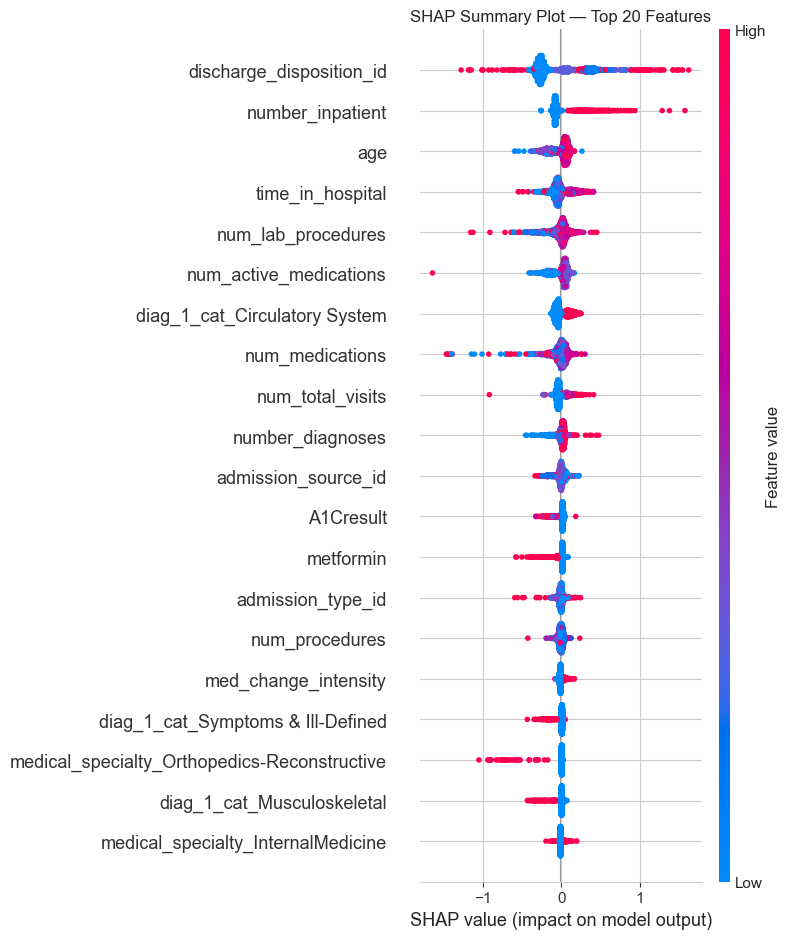

In [44]:
# Global feature importance — shows top features and how their values affect predictions
# Red = high feature value, Blue = low feature value
# Position on x-axis = impact on prediction (right = pushes toward readmission)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot — Top 20 Features')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

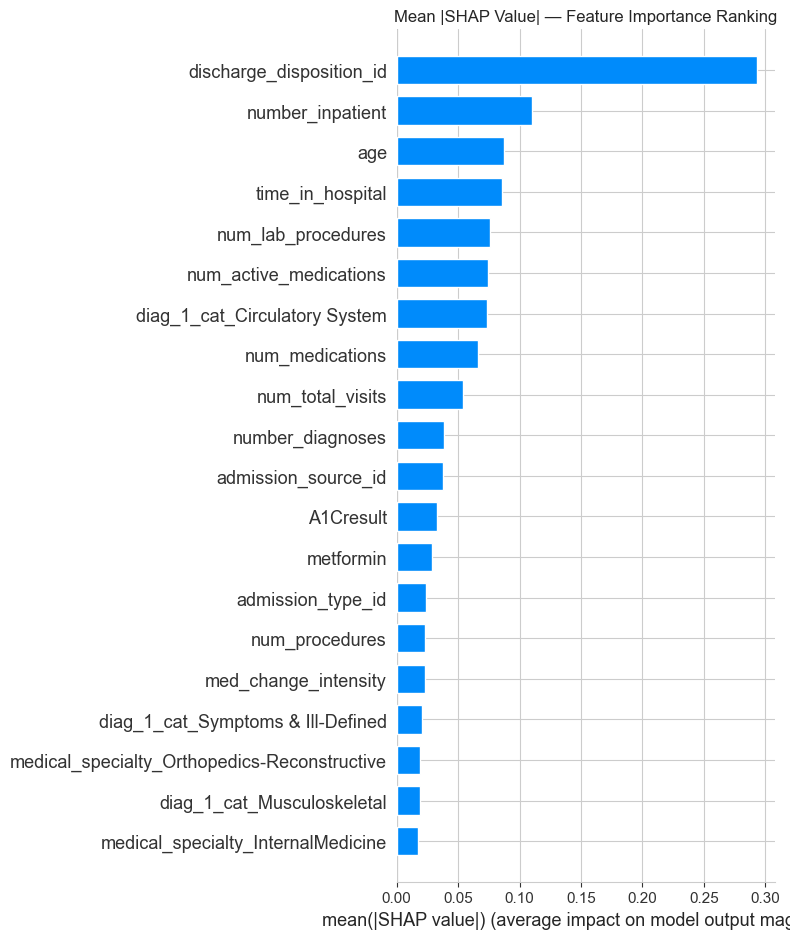

In [45]:
# Simpler bar chart of mean absolute SHAP values
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar', max_display=20, show=False)
plt.title('Mean |SHAP Value| — Feature Importance Ranking')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### **SHAP Analysis Findings:**

**Top 5 most important features:**

1. **discharge_disposition_id** — by far the most influential feature, confirming our EDA finding. The summary plot shows that higher values (transfers to rehab/nursing facilities) push predictions toward readmission (red dots on the right), while lower values (discharged home) push away from readmission
2. **number_inpatient** — the second strongest predictor. Higher values (more prior hospitalisations) clearly increase readmission risk — the red dots cluster on the right side, consistent with the "frequent flyer" pattern
3. **age** — older patients (red/high values) are pushed toward readmission, younger patients (blue/low values) away from it, matching the age trend we saw in EDA
4. **time_in_hospital** — longer stays increase readmission risk, likely because they indicate more complex clinical cases
5. **num_lab_procedures** — higher numbers of lab tests suggest diagnostic complexity, which increases readmission risk

**Clinical insights from SHAP directions:**
- **num_active_medications** — more active medications pushes toward readmission, indicating patients on complex drug regimens are harder to manage post-discharge
- **diag_1_cat_Circulatory System** — having a circulatory primary diagnosis increases readmission risk, consistent with the known link between cardiovascular comorbidities and diabetes complications
- **A1Cresult** — higher A1C results (indicating poor blood sugar control) push toward readmission, which is clinically intuitive
- **metformin** — appears in the top 15, suggesting that metformin prescribing patterns carry some predictive signal

**Key takeaway:** The model's top features are clinically meaningful — discharge destination, prior hospitalisations, age, and stay length are all factors that clinicians would recognise as relevant. This increases the model's trustworthiness for clinical use.

## Confusion Matrix — Best Model

The confusion matrix shows exactly where the model gets things right and wrong. For a clinical screening tool, we care most about:
- **True Positives:** readmitted patients correctly identified (good — they get extra support)
- **False Negatives:** readmitted patients missed by the model (bad — they slip through)
- **False Positives:** non-readmitted patients incorrectly flagged (less bad — they receive unnecessary follow-up, which wastes resources but doesn't harm them)

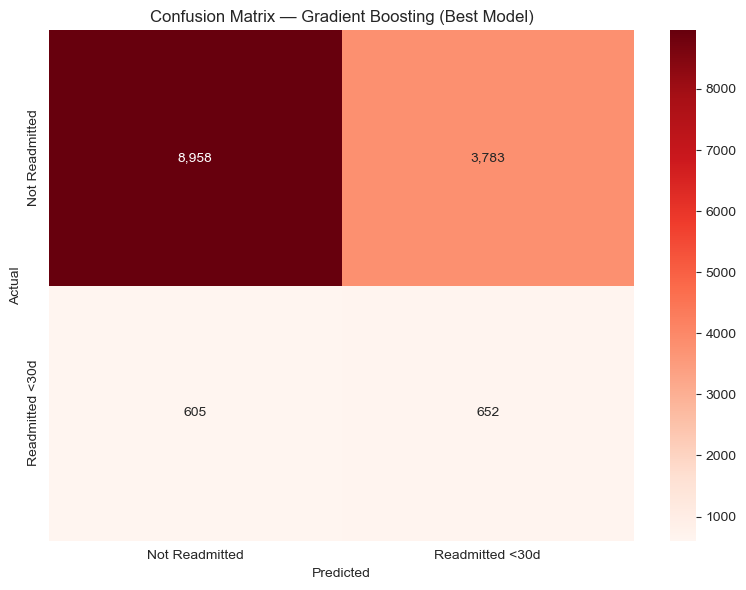

True Negatives (correctly predicted not readmitted):  8,958
False Positives (incorrectly flagged as readmitted):  3,783
False Negatives (missed readmissions):                605
True Positives (correctly caught readmissions):       652

Of 1,257 actual readmissions, the model caught 652 (51.9%)
Of 4,435 patients flagged, 652 were actually readmitted (14.7%)


In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Reds', ax=ax,
            xticklabels=['Not Readmitted', 'Readmitted <30d'],
            yticklabels=['Not Readmitted', 'Readmitted <30d'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Gradient Boosting (Best Model)')

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted not readmitted):  {tn:,}")
print(f"False Positives (incorrectly flagged as readmitted):  {fp:,}")
print(f"False Negatives (missed readmissions):                {fn:,}")
print(f"True Positives (correctly caught readmissions):       {tp:,}")
print(f"\nOf {tp + fn:,} actual readmissions, the model caught {tp:,} ({tp/(tp+fn)*100:.1f}%)")
print(f"Of {tp + fp:,} patients flagged, {tp:,} were actually readmitted ({tp/(tp+fp)*100:.1f}%)")

### **Confusion Matrix Findings:**

The model flags 4,435 patients as high-risk (652 + 3,783), but only 652 of them actually get readmitted — that's a lot of false alarms. However, consider the trade-off:

- **652 true positives** — these patients were correctly identified and could receive targeted interventions (follow-up calls, medication reviews, earlier appointments)
- **605 false negatives** — these readmitted patients were missed by the model
- **3,783 false positives** — these patients were flagged but not readmitted

**Is this acceptable clinically?** It depends on the intervention cost:
- If the intervention is a **phone call** (low cost, no harm), then flagging 4,435 patients to catch 652 readmissions is reasonable — the cost of a wasted call is minimal compared to the cost of a preventable readmission
- If the intervention is **extending the hospital stay** (high cost), then 3,783 unnecessary extended stays would be unacceptable

This is exactly why the threshold analysis in the next section matters — we can adjust how aggressive the model is based on what the intervention actually is.

## Clinical Decision Threshold Analysis

The default classification threshold is 0.5, but this isn't necessarily optimal for a clinical tool. By lowering the threshold, we can catch more readmitted patients (higher recall) at the cost of more false alarms. The right threshold depends on the clinical context — how costly is a missed readmission vs an unnecessary follow-up call?

In [47]:
# Test different thresholds for the best model
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

print(f"{'Threshold':>10s} {'Recall':>10s} {'Precision':>12s} {'Flagged':>10s} {'Caught':>10s}")
print(f"{'-'*55}")

for thresh in thresholds:
    preds = (gb_proba >= thresh).astype(int)
    cm_t = confusion_matrix(y_test, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    recall = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    precision = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    flagged = tp_t + fp_t
    print(f"{thresh:>10.2f} {recall:>10.1%} {precision:>12.1%} {flagged:>10,} {tp_t:>10,}")

 Threshold     Recall    Precision    Flagged     Caught
-------------------------------------------------------
      0.05     100.0%         9.0%     13,992      1,257
      0.10      99.5%         9.0%     13,915      1,251
      0.15      98.7%         9.1%     13,710      1,241
      0.20      97.9%         9.3%     13,250      1,231
      0.25      96.3%         9.7%     12,467      1,210
      0.30      91.4%        10.1%     11,346      1,149
      0.40      75.4%        11.9%      7,984        948
      0.50      51.9%        14.7%      4,435        652


#### **Threshold Analysis Findings:**

The table reveals the core trade-off a hospital would face when deploying this model:

| Scenario | Threshold | What happens |
|---|---|---|
| **Catch everyone** | 0.05 | 100% recall — all 1,257 readmissions caught, but you flag 13,992 patients (nearly the entire test set). Only 9% of flagged patients actually get readmitted. |
| **Balanced** | 0.30 | 91.4% recall — catches 1,149 of 1,257 readmissions while flagging 11,346. Still noisy but misses very few. |
| **Default (0.50)** | 0.50 | 51.9% recall — catches 652 readmissions but misses 605. Flags fewer patients (4,435) with slightly better precision (14.7%). |

**Recommended threshold: 0.30**

At this threshold, the model catches **91.4% of readmissions** while flagging 11,346 patients. This works well if the intervention is low-cost and low-harm — for example:
- Automated discharge follow-up calls
- Flagging patients for pharmacist medication review
- Prioritising discharge planning nurse visits

The key insight is that **no single threshold is "correct"** — it depends entirely on the clinical context. This threshold analysis gives hospital administrators the data they need to make that decision for their specific situation.

In [48]:
import joblib

# Save the best model and the scaler
joblib.dump(gb_model, '../outputs/gb_model.pkl')
joblib.dump(scaler, '../outputs/scaler.pkl')

# Save the feature names so Streamlit knows the expected input format
feature_names = list(X.columns)
joblib.dump(feature_names, '../outputs/feature_names.pkl')

print("Saved:")
print(f"  Model:         outputs/gb_model.pkl")
print(f"  Scaler:        outputs/scaler.pkl")
print(f"  Feature names: outputs/feature_names.pkl ({len(feature_names)} features)")

Saved:
  Model:         outputs/gb_model.pkl
  Scaler:        outputs/scaler.pkl
  Feature names: outputs/feature_names.pkl (98 features)


# Conclusion

## Summary of Results

This project built an end-to-end machine learning pipeline to predict 30-day hospital readmission for diabetic patients using the UCI Diabetes 130-US Hospitals dataset.

**Best model:** Gradient Boosting with class weighting
- **ROC-AUC:** 0.6539
- **Average Precision:** 0.1765
- **Recall:** 52% of readmitted patients correctly identified (91.4% at threshold 0.30)

## Key Findings

1. **30-day readmission is inherently difficult to predict** from structured clinical data alone — all models achieved modest ROC-AUC scores (0.63–0.65), consistent with published research on this dataset
2. **Class weighting outperformed SMOTE** for handling class imbalance — SMOTE degraded performance across all models, likely due to noise introduced by interpolating sparse one-hot encoded features
3. **Discharge destination is the strongest predictor** — patients transferred to rehab or nursing facilities have 2–3x the readmission rate of those discharged home
4. **Prior inpatient visits is the second strongest predictor** — patients with a history of hospitalisations are at significantly higher risk of readmission
5. **Comorbidities matter more than diabetes itself** — only 8.2% of patients had diabetes as their primary diagnosis, yet circulatory and mental health conditions showed elevated readmission rates

## Clinical Implications

Even with modest predictive performance, a model like this can be used as a **screening tool** rather than a diagnostic one. By adjusting the decision threshold, hospitals can flag high-risk patients for additional discharge planning — follow-up calls, medication reviews, or earlier outpatient appointments — potentially reducing avoidable readmissions and the financial penalties associated with them.

## Limitations and Future Work

- **Feature limitations:** The dataset lacks important predictors such as lab result values, medication adherence, socioeconomic factors, and clinical notes
- **Temporal considerations:** The data spans 1999–2008, clinical practices and readmission patterns may have changed significantly since then
- **Model improvements:** XGBoost, LightGBM, or neural networks could be explored for marginal gains
- **External validation:** The model should be tested on data from different hospital systems before clinical deployment